# Pipeline de Dados e Modelo

## 1. Preparação dos Dados

In [1]:
%pip install -r requirements.txt

import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("sst2023/kdd-cup-2015")
print(f"Dataset baixado em: {path}")
path_csv = os.path.join(path, "train", "train")

# Carregando os logs (eventos) com as colunas relevantes
logs = pd.read_csv(
  os.path.join(path_csv, 'log_train.csv'),
  usecols=['enrollment_id', 'time', 'event'],
  parse_dates=['time']
)

# Carregando matriculas para saber quais alunos sao
enroll = pd.read_csv(
  os.path.join(path_csv, 'enrollment_train.csv'),
  usecols=['enrollment_id', 'username', 'course_id']
)

# Juntar para ter um id de usuario (username) associado a cada evento
logs = logs.merge(enroll[['enrollment_id','username']], on='enrollment_id', how='left')

print(f"Total de eventos: {len(logs)}\n")
print(f"Exemplo de dados:")
print(logs.head())

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Dataset baixado em: /home/administrador/.cache/kagglehub/datasets/sst2023/kdd-cup-2015/versions/1
Total de eventos: 8157277

Exemplo de dados:
   enrollment_id                time     event  \
0              1 2014-06-14 09:38:29  navigate   
1              1 2014-06-14 09:38:39    access   
2              1 2014-06-14 09:38:39    access   
3              1 2014-06-14 09:38:48    access   
4              1 2014-06-14 09:41:49   problem   

                           username  
0  9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0  
1  9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0  
2  9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0  
3  9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0  
4  9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0  


In [2]:
# Contar quantos eventos cada usuario possui
eventos_por_usuario = logs.groupby('username')['enrollment_id'].nunique().reset_index()
eventos_por_usuario.columns = ['username', 'num_eventos']

# Filtrar usuarios com pelo menos 1 evento
usuarios_com_eventos = eventos_por_usuario[eventos_por_usuario['num_eventos'] > 0]

print(f"Número total de usuários ativos: {len(usuarios_com_eventos)}\n")

# Amostrar 300 usuarios ativos aleatoriamente
amostra_usuarios_final = usuarios_com_eventos.sample(n=300, random_state=42)['username'].tolist()

# Exibir alguns usuarios amostrados
print(f"Usuários amostrados:")
print(amostra_usuarios_final[:5])

Número total de usuários ativos: 79186

Usuários amostrados:
['7otzZejUP2vT9d3vrInOSUhXf2yFg4Ih', 'GpDja7A8WYJ6Pm0TB6WZqwv2e9M9V3CK', '7yphMCe2LQupOHSaDA3UQC9kbDeEuBie', 'iq2s6XEtLNjMdyc7MReRkWOgf3bnXnky', 'W1zZHCfqRXlJ4Ptepv9MTAPPHdMhS2yc']


In [3]:
# Filtrar os eventos para incluir apenas os dos usuários amostrados
logs_amostra = logs[logs['username'].isin(amostra_usuarios_final)]

# Verificar a quantidade de eventos que sobraram
print(f"Total de eventos na amostra: {len(logs_amostra)}\n")
print(f"Exemplo de eventos na amostra:")
print(logs_amostra.head())

Total de eventos na amostra: 27872

Exemplo de eventos na amostra:
       enrollment_id                time     event  \
63049            482 2014-06-20 16:17:08  navigate   
63050            482 2014-06-20 16:17:17  navigate   
63051            482 2014-06-20 16:18:24    access   
63052            482 2014-06-20 16:18:24    access   
63053            482 2014-06-20 16:18:53    access   

                               username  
63049  CROimDxOHTGrmo0KgYAQthGd8AcAioLZ  
63050  CROimDxOHTGrmo0KgYAQthGd8AcAioLZ  
63051  CROimDxOHTGrmo0KgYAQthGd8AcAioLZ  
63052  CROimDxOHTGrmo0KgYAQthGd8AcAioLZ  
63053  CROimDxOHTGrmo0KgYAQthGd8AcAioLZ  


In [4]:
# Salvar a amostra de eventos em um novo arquivo CSV
logs_amostra.to_csv('data/logs_amostra.csv', index=False)
print("Amostra de eventos salva em 'data/logs_amostra.csv'")

Amostra de eventos salva em 'data/logs_amostra.csv'


In [5]:
# Carregar labels de dropout (truth_train.csv)
truth = pd.read_csv(
    os.path.join(path_csv, 'truth_train.csv'),
    header=None,
    names=['enrollment_id', 'dropout']
)

print(f"Total de labels: {len(truth)}")
print(f"Taxa de evasão geral: {truth['dropout'].mean():.2%}")
print(truth.head())

Total de labels: 120542
Taxa de evasão geral: 79.29%
   enrollment_id  dropout
0              1        0
1              3        0
2              4        0
3              5        0
4              6        0


In [6]:
# Obter enrollment_ids dos usuarios amostrados
enroll_amostra = enroll[enroll['username'].isin(amostra_usuarios_final)].copy()
print(f"Matrículas dos usuários amostrados: {len(enroll_amostra)}")

# Juntar com labels de dropout
labels_amostra = enroll_amostra.merge(truth, on='enrollment_id', how='left')
print(f"Matrículas com label: {labels_amostra['dropout'].notna().sum()}")
print(f"Taxa de evasão na amostra: {labels_amostra['dropout'].mean():.2%}")
print(labels_amostra.head())

Matrículas dos usuários amostrados: 442
Matrículas com label: 442
Taxa de evasão na amostra: 80.09%
   enrollment_id                          username  \
0            482  CROimDxOHTGrmo0KgYAQthGd8AcAioLZ   
1            865  R10XK8pdFXA5if2l3INj2xLIWXYQsEhc   
2           1714  XB4WTxkP3vNmHXjALkkfZII5POid4TAu   
3           2925  YFbuiDgxEqp9ZojSNevgtnFcnDrGcdej   
4           3002  A27U0Te0bawcJtUahe4rjfAA0l9tgJqM   

                          course_id  dropout  
0  DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila        0  
1  DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila        0  
2  DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila        1  
3  81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv        0  
4  81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv        1  


In [7]:
# Salvar dados complementares
enroll_amostra.to_csv('data/enroll_amostra.csv', index=False)
labels_amostra.to_csv('data/labels_amostra.csv', index=False)

print("Salvo: data/enroll_amostra.csv  (username, enrollment_id, course_id)")
print("Salvo: data/labels_amostra.csv  (username, enrollment_id, course_id, dropout)")

Salvo: data/enroll_amostra.csv  (username, enrollment_id, course_id)
Salvo: data/labels_amostra.csv  (username, enrollment_id, course_id, dropout)


## 2. Extração de Features Semanais

Transforma os logs de eventos em features por `(username, semana)` para alimentar o modelo de predição de dropout.

In [8]:
# Carregar dados preparados
logs = pd.read_csv('data/logs_amostra.csv', parse_dates=['time'])
labels = pd.read_csv('data/labels_amostra.csv')
enroll = pd.read_csv('data/enroll_amostra.csv')

print(f"Eventos: {len(logs):,}")
print(f"Matrículas: {len(labels):,}")
print(f"Tipos de evento: {logs['event'].unique()}")
print(f"Período: {logs['time'].min()} → {logs['time'].max()}")

Eventos: 27,872
Matrículas: 442
Tipos de evento: ['navigate' 'access' 'page_close' 'video' 'discussion' 'wiki' 'problem']
Período: 2013-10-30 04:18:00 → 2014-07-31 11:31:57


In [9]:
# Associar enrollment_id a course_id em cada evento
logs = logs.merge(enroll[['enrollment_id', 'course_id']], on='enrollment_id', how='left')

# Calcular semana relativa ao início de cada matrícula
# Usamos a data mínima de evento por enrollment_id como referência
inicio_matricula = logs.groupby('enrollment_id')['time'].min().rename('inicio')
logs = logs.merge(inicio_matricula, on='enrollment_id')
logs['dias_desde_inicio'] = (logs['time'] - logs['inicio']).dt.days
logs['semana'] = (logs['dias_desde_inicio'] // 7).clip(upper=9)  # máx 10 semanas (0..9)

print(f"Distribuição de semanas:")
print(logs['semana'].value_counts().sort_index())

Distribuição de semanas:
semana
0    15300
1     5171
2     4314
3     2433
4      654
Name: count, dtype: int64


In [10]:
# Contagem de sessões: gaps > 30 minutos = nova sessão
logs_sorted = logs.sort_values(['enrollment_id', 'time'])
logs_sorted['gap'] = logs_sorted.groupby('enrollment_id')['time'].diff().dt.total_seconds().fillna(9999)
logs_sorted['nova_sessao'] = (logs_sorted['gap'] > 1800).astype(int)

# Features por (username, semana)
event_types = ['navigate', 'access', 'problem', 'video', 'wiki', 'page_close', 'discussion']

grp = logs_sorted.groupby(['username', 'semana'])

features = grp.agg(
    total_events=('event', 'count'),
    sessoes=('nova_sessao', 'sum'),
    dias_ativos=('time', lambda x: x.dt.date.nunique())
).reset_index()

# Contagem por tipo de evento (pivot)
event_counts = logs_sorted.groupby(['username', 'semana', 'event']).size().unstack(fill_value=0).reset_index()
for et in event_types:
    if et not in event_counts.columns:
        event_counts[et] = 0

keep_cols = ['username', 'semana'] + [et for et in event_types if et in event_counts.columns]
features = features.merge(event_counts[keep_cols], on=['username', 'semana'], how='left')

print(f"Features shape: {features.shape}")
print(features.head())

Features shape: (490, 12)
                           username  semana  total_events  sessoes  \
0  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       0             1        1   
1  0UfP07I2iwfwmlnUahvfksC7lbNr2lOS       0            35        3   
2  0cYWNkHgs2RcwIgdJDj7HBHLPSVvxwGW       0             1        1   
3  0ghe43x8DU4ZKEP2rwt8HDtWNCmUsBMb       0             4        2   
4  0imlHd8ftsLmPgrGO2UbPV6PyVbAOKOc       0            16        1   

   dias_ativos  navigate  access  problem  video  wiki  page_close  discussion  
0            1         1       0        0      0     0           0           0  
1            2         8      17        0      5     0           5           0  
2            1         1       0        0      0     0           0           0  
3            1         1       2        0      0     0           1           0  
4            1        14       0        0      0     2           0           0  


In [11]:
# Garantir todas as semanas (0..9) para cada usuário
# Criar grade completa e preencher ausências com zero
usuarios = logs['username'].unique()
semanas = list(range(10))
grade = pd.MultiIndex.from_product([usuarios, semanas], names=['username', 'semana'])
features = features.set_index(['username', 'semana']).reindex(grade, fill_value=0).reset_index()

print(f"Features completas: {features.shape}")
print(f"Usuários: {features['username'].nunique()} × Semanas: {features['semana'].nunique()}")

Features completas: (3000, 12)
Usuários: 300 × Semanas: 10


In [12]:
# Tendência: variação de eventos em relação à semana anterior
features = features.sort_values(['username', 'semana'])
features['tendencia_eventos'] = features.groupby('username')['total_events'].diff().fillna(0)

# Média acumulada de eventos (engajamento histórico)
features['media_acumulada'] = (
    features.groupby('username')['total_events']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

# Semanas consecutivas sem atividade
features['inativo'] = (features['total_events'] == 0).astype(int)
features['semanas_inativas_consec'] = (
    features.groupby('username')['inativo']
    .transform(lambda x: x.groupby((x != x.shift()).cumsum()).cumcount() + 1) * features['inativo']
)

print(f"Features com tendência: {features.shape}")
print(features[['username','semana','total_events','tendencia_eventos','semanas_inativas_consec']].head(15))

Features com tendência: (3000, 16)
                             username  semana  total_events  \
330  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       0             1   
331  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       1             0   
332  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       2             0   
333  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       3             0   
334  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       4             0   
335  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       5             0   
336  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       6             0   
337  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       7             0   
338  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       8             0   
339  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       9             0   
370  0UfP07I2iwfwmlnUahvfksC7lbNr2lOS       0            35   
371  0UfP07I2iwfwmlnUahvfksC7lbNr2lOS       1             0   
372  0UfP07I2iwfwmlnUahvfksC7lbNr2lOS       2             0   
373  0UfP07I2iwfwmlnUahvfksC7lbNr2lOS       3             0   
374  0UfP07I2iwfwmln

In [13]:
# Juntar com label de dropout (por username, pegando o label mais comum por usuário)
# Um usuário pode ter múltiplas matrículas; usamos o pior caso (dropout=1 se evasão em qualquer)
label_por_usuario = labels.groupby('username')['dropout'].max().reset_index()
label_por_usuario.columns = ['username', 'dropout']

features = features.merge(label_por_usuario, on='username', how='left')

print(f"Taxa de evasão na amostra: {features['dropout'].mean():.2%}")
print(f"NaN no dropout: {features['dropout'].isna().sum()}")

# Preencher NaN com 0 (sem label = considerado não-evasão)
features['dropout'] = features['dropout'].fillna(0).astype(int)

print(f"\nShape final: {features.shape}")
print(features.head())

Taxa de evasão na amostra: 84.67%
NaN no dropout: 0

Shape final: (3000, 17)
                           username  semana  total_events  sessoes  \
0  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       0             1        1   
1  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       1             0        0   
2  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       2             0        0   
3  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       3             0        0   
4  0EjKvRTxPK4ozZ3L3wWm5nTPbXNczvrz       4             0        0   

   dias_ativos  navigate  access  problem  video  wiki  page_close  \
0            1         1       0        0      0     0           0   
1            0         0       0        0      0     0           0   
2            0         0       0        0      0     0           0   
3            0         0       0        0      0     0           0   
4            0         0       0        0      0     0           0   

   discussion  tendencia_eventos  media_acumulada  inativo  \
0           0      

In [14]:
# Salvar
features.to_csv('data/features.csv', index=False)
print("Salvo: data/features.csv")
print(f"Colunas: {list(features.columns)}")

Salvo: data/features.csv
Colunas: ['username', 'semana', 'total_events', 'sessoes', 'dias_ativos', 'navigate', 'access', 'problem', 'video', 'wiki', 'page_close', 'discussion', 'tendencia_eventos', 'media_acumulada', 'inativo', 'semanas_inativas_consec', 'dropout']


## 3. Modelo de Predição de Dropout e Estimativa de Ganho

1. Treinar LightGBM para estimar `P(dropout | features até semana t)`
2. Gerar `risk[i,t]` = probabilidade de evasão do aluno `i` na semana `t`
3. Calcular `gain[i,t,r] = risk[i,t] × effectiveness[r]` para 3 tipos de intervenção

In [15]:
import pickle
import warnings
warnings.filterwarnings('ignore')

features_df = pd.read_csv('data/features.csv')

print(f"Shape: {features_df.shape}")
print(f"Colunas: {list(features_df.columns)}")
print(f"Usuários: {features_df['username'].nunique()}")
print(f"Semanas: {sorted(features_df['semana'].unique())}")
print(f"Taxa dropout: {features_df['dropout'].mean():.2%}")

Shape: (3000, 17)
Colunas: ['username', 'semana', 'total_events', 'sessoes', 'dias_ativos', 'navigate', 'access', 'problem', 'video', 'wiki', 'page_close', 'discussion', 'tendencia_eventos', 'media_acumulada', 'inativo', 'semanas_inativas_consec', 'dropout']
Usuários: 300
Semanas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Taxa dropout: 84.67%


In [16]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb

FEATURE_COLS = [
    'semana', 'total_events', 'sessoes', 'dias_ativos',
    'navigate', 'access', 'problem', 'video', 'wiki', 'page_close', 'discussion',
    'tendencia_eventos', 'media_acumulada', 'semanas_inativas_consec'
]
# Manter apenas colunas que existem
FEATURE_COLS = [c for c in FEATURE_COLS if c in features_df.columns]
print(f"Features usadas: {FEATURE_COLS}")

X = features_df[FEATURE_COLS].values
y = features_df['dropout'].values
groups = features_df['username'].values

Features usadas: ['semana', 'total_events', 'sessoes', 'dias_ativos', 'navigate', 'access', 'problem', 'video', 'wiki', 'page_close', 'discussion', 'tendencia_eventos', 'media_acumulada', 'semanas_inativas_consec']


In [17]:
# Cross-validation por usuário (GroupKFold evita data leakage entre semanas do mesmo aluno)
gkf = GroupKFold(n_splits=5)

oof_probs = np.zeros(len(X))
auc_scores = []

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 200,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_child_samples': 5,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'random_state': 42,
    'verbose': -1
}

models = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)]
    )
    oof_probs[val_idx] = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, oof_probs[val_idx])
    auc_scores.append(auc)
    models.append(model)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

print(f"\nAUC médio: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

  Fold 1: AUC = 0.8034
  Fold 2: AUC = 0.7363
  Fold 3: AUC = 0.6847
  Fold 4: AUC = 0.7559
  Fold 5: AUC = 0.7679

AUC médio: 0.7497 ± 0.0391


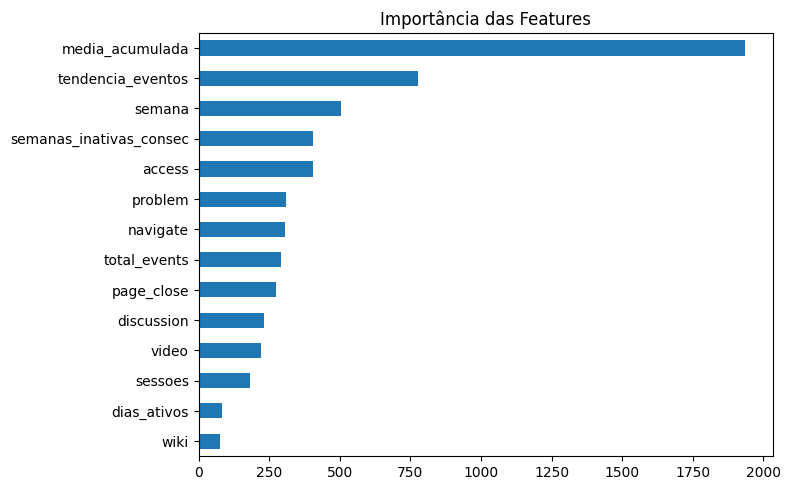

media_acumulada            1937
tendencia_eventos           778
semana                      504
semanas_inativas_consec     406
access                      406
problem                     309
navigate                    304
total_events                290
page_close                  274
discussion                  233
video                       221
sessoes                     181
dias_ativos                  83
wiki                         74
dtype: int32


In [18]:
# Treinar modelo final em todos os dados para geração dos risk scores
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y, callbacks=[lgb.log_evaluation(0)])

# Importância das features
import matplotlib.pyplot as plt

importances = pd.Series(final_model.feature_importances_, index=FEATURE_COLS)
importances.sort_values().plot(kind='barh', figsize=(8, 5), title='Importância das Features')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=120)
plt.show()
print(importances.sort_values(ascending=False))

In [19]:
# Gerar risk[i,t] = probabilidade de dropout por (username, semana)
features_df['risk'] = final_model.predict_proba(X)[:, 1]

print(f"Risk médio: {features_df['risk'].mean():.3f}")
print(f"Risk por semana:")
print(features_df.groupby('semana')['risk'].mean().round(3))

Risk médio: 0.847
Risk por semana:
semana
0    0.846
1    0.845
2    0.848
3    0.844
4    0.845
5    0.847
6    0.847
7    0.848
8    0.848
9    0.850
Name: risk, dtype: float64


In [20]:
# Definição dos tipos de intervenção sintéticos
INTERVENCOES = {
    'R1_email': {'custo': 1, 'efetividade': 0.15, 'descricao': 'Email de lembrete'},
    'R2_tutor': {'custo': 5, 'efetividade': 0.45, 'descricao': 'Contato com tutor'},
    'R3_recuperacao': {'custo': 2, 'efetividade': 0.25, 'descricao': 'Atividade de recuperação'},
}

# Calcular gain[i,t,r] = risk[i,t] * effectiveness[r]
# Representado como dicionário indexado por (username, semana, tipo_interv)
gains_records = []
for _, row in features_df.iterrows():
    for tipo, params in INTERVENCOES.items():
        gains_records.append({
            'username': row['username'],
            'semana': int(row['semana']),
            'tipo_interv': tipo,
            'custo': params['custo'],
            'efetividade': params['efetividade'],
            'risk': row['risk'],
            'gain': row['risk'] * params['efetividade'],
            'dropout': int(row['dropout'])
        })

gains_df = pd.DataFrame(gains_records)
print(f"Shape matriz de ganhos: {gains_df.shape}")
print(f"Ganho médio por tipo:")
print(gains_df.groupby('tipo_interv')['gain'].describe().round(4))

Shape matriz de ganhos: (9000, 8)
Ganho médio por tipo:
                 count    mean     std     min     25%     50%     75%     max
tipo_interv                                                                   
R1_email        3000.0  0.1270  0.0314  0.0031  0.1262  0.1395  0.1444  0.1498
R2_tutor        3000.0  0.3810  0.0942  0.0092  0.3787  0.4184  0.4333  0.4494
R3_recuperacao  3000.0  0.2117  0.0523  0.0051  0.2104  0.2324  0.2407  0.2496


In [21]:
# Salvar
gains_df.to_csv('data/gains.csv', index=False)

with open('data/gains.pkl', 'wb') as f:
    pickle.dump({
        'gains_df': gains_df,
        'intervencoes': INTERVENCOES,
        'model': final_model,
        'feature_cols': FEATURE_COLS,
        'auc_scores': auc_scores
    }, f)

print("Salvo: data/gains.csv")
print("Salvo: data/gains.pkl")
print(f"\nResumo:")
print(f"  Usuários: {gains_df['username'].nunique()}")
print(f"  Semanas: {gains_df['semana'].nunique()}")
print(f"  Tipos de intervenção: {gains_df['tipo_interv'].nunique()}")
print(f"  Total de variáveis de decisão possíveis: {len(gains_df)}")

Salvo: data/gains.csv
Salvo: data/gains.pkl

Resumo:
  Usuários: 300
  Semanas: 10
  Tipos de intervenção: 3
  Total de variáveis de decisão possíveis: 9000
